# **Business Case: Aerofit - Descriptive Statistics & Probability**

##**Submitted By: Aravinth Baskar**

#1. Business Problem

Aerofit offers three treadmill models catering to customers with different fitness needs and budgets. The company wants to better understand the characteristics of customers purchasing each product so that it can recommend the most suitable treadmill to future customers.

In this case study, we will analyze customer demographics, income, fitness levels, and expected treadmill usage to identify purchasing patterns. Based on the analysis, we will build customer profiles for each treadmill model, calculate purchase probabilities, and provide actionable business recommendations.

# 2. Dataset Description

The dataset contains information about customers who purchased an Aerofit treadmill during the previous three months. Each record represents an individual customer and includes the following attributes:

- **Product:** Treadmill model purchased (KP281, KP481, or KP781)
- **Age:** Age of the customer (in years)
- **Gender:** Gender of the customer (Male/Female)
- **Education:** Years of education completed
- **MaritalStatus:** Marital status of the customer (Single or Partnered)
- **Usage:** Average number of times the customer plans to use the treadmill each week
- **Income:** Annual income of the customer (in USD)
- **Fitness:** Self-rated fitness level on a scale of 1 to 5, where 1 represents poor fitness and 5 represents excellent fitness
- **Miles:** Average number of miles the customer expects to walk/run each week

# 3. Importing Required Libraries

The following libraries are imported for data manipulation and visualization. These libraries will be used throughout the analysis to explore the dataset and derive meaningful business insights.

In [ ]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Loading the Dataset

The dataset is loaded into a Pandas DataFrame to begin the exploratory data analysis.

In [ ]:
!gdown 1MFKFyxKjLlmmUJJxXZhD1YATCWLagNnZ

Downloading...
From: https://drive.google.com/uc?id=1MFKFyxKjLlmmUJJxXZhD1YATCWLagNnZ
To: /content/aerofit_treadmill.csv
100% 7.28k/7.28k [00:00<00:00, 19.4MB/s]


In [ ]:
df = pd.read_csv("aerofit_treadmill.csv")

# 5. Data Understanding

Before performing the analysis, this section explores the dataset by examining its records, dimensions, data types, summary statistics and data quality.

## 5.1 Data Preview

Let's examine the first 3 rowsthe dataset to understand its structure and the values present in each feature.

In [ ]:
df.head(3)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66


## 5.2 Dataset Dimensions

The shape of the dataset provides the total number of rows and columns available for analysis.

In [ ]:
df.shape

(180, 9)

## 5.3 Dataset Information

The dataset information provides details about each column, including its data type, non-null count and memory usage.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


## 5.4 Unique Values in Each Feature

This section examines the number of unique values present in each feature. It provides an overview of the diversity of the dataset and helps distinguish between numerical and categorical variables.

In [ ]:
df.nunique()

,0
Product,3
Age,32
Gender,2
Education,8
MaritalStatus,2
Usage,6
Fitness,5
Income,62
Miles,37


## 5.5 Missing Values

Checking for missing values is an important step in assessing data quality. Missing values, if present, may require appropriate handling before analysis.

In [ ]:
df.isna().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


## 5.6 Duplicate Records

Duplicate records can introduce bias in the analysis. Therefore, it is important to check whether the dataset contains any duplicated observations.


In [ ]:
df.duplicated().sum()

np.int64(0)

## 5.7 Feature Type Conversion

The categorical variables are converted from the object data type to the category data type to better represent their nature and improve memory efficiency.


In [ ]:
cat_cols = ['Product', 'Gender', 'MaritalStatus']

df[cat_cols] = df[cat_cols].astype('category')

## 5.8 Summary of Data Understanding

- The dataset contains 180 customer rows and 9 columns, providing information on customer demographics, lifestyle, fitness level, income, and treadmill purchases.
- The dataset consists of both categorical and numerical columns, making it suitable for a combination of descriptive and comparative analysis.
- No missing values or duplicate records were found, indicating that the dataset is complete and does not require data cleaning.
- The categorical variables Product, Gender, and MaritalStatus were converted from the object data type to the category data type to better represent their nature and improve memory efficiency.
- Overall, the dataset is clean, well-structured, and ready for exploratory data analysis (EDA).



# 6. Missing Value & Outlier Analysis

To ensure the dataset is suitable for exploratory data analysis, it is important to assess its quality by examining missing values and identifying potential outliers. This section summarizes the missing value assessment and evaluates the presence of outliers in the numerical features.

## 6.1 Missing Value Analysis

The missing value assessment performed during the **Data Understanding** phase confirmed that the dataset contains **no missing values**. Therefore, no missing value treatment is required before proceeding with the analysis.

## 6.2 Outlier Detection

Outliers are observations that lie significantly outside the typical range of a variable. Identifying outliers helps determine whether they represent genuine customer characteristics or potential data anomalies. In this analysis, boxplots are used to detect potential outliers in the numerical features.

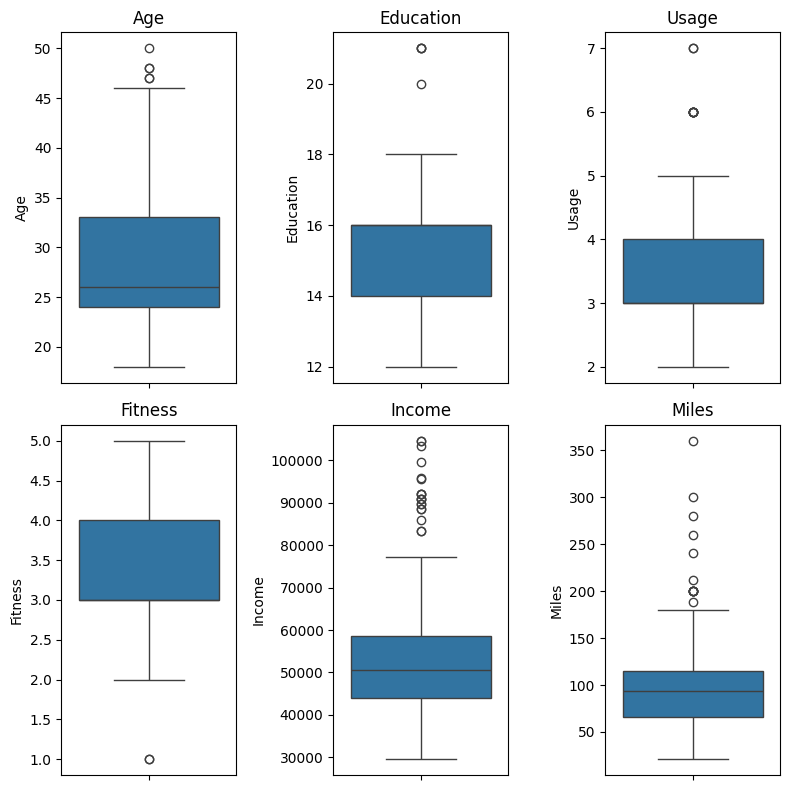

In [ ]:
df_numericals = df.loc[:, df.dtypes == 'int64']
num_cols = df_numericals.columns

plt.figure(figsize=(8, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## 6.3 Outlier Analysis Summary

- Potential outliers are observed in Age, Education, Usage, Fitness, Income and Miles.
- The outliers in Income and Miles are more prominent, indicating the presence of customers with relatively higher income levels and expected weekly mile count.
- The identified outliers appear to represent genuine customer characteristics rather than data entry errors.
- Therefore, no outlier treatment is performed, and all observations are retained for further analysis.

# 7. Non-Graphical Analysis

Non-graphical analysis explores the relationships and distributions within the dataset using summary tables and descriptive statistics without relying on visualizations. This section focuses on understanding customer characteristics and product preferences through tabular analysis.

## 7.1 Summary Statistics - Numerical Features

Summary statistics provide an overview of the numerical features by describing their central tendency, variability, and distribution. This helps in understanding the overall characteristics of the customers.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,180.0,28.788889,6.943498,18.0,24.00,26.0,33.00,50.0
Education,180.0,15.572222,1.617055,12.0,14.00,16.0,16.00,21.0
Usage,180.0,3.455556,1.084797,2.0,3.00,3.0,4.00,7.0
Fitness,180.0,3.311111,0.958869,1.0,3.00,3.0,4.00,5.0
Income,180.0,53719.577778,16506.684226,29562.0,44058.75,50596.5,58668.00,104581.0
Miles,180.0,103.194444,51.863605,21.0,66.00,94.0,114.75,360.0


### Key Observations

- Customer ages range from young adults(18) to senior individuals(50), indicating a diverse customer base.
- Annual income exhibits the widest range among all numerical features, suggesting considerable variation in customers' purchasing power.
- Expected weekly mile count also shows substantial variability, reflecting different fitness goals and usage patterns.
- The average fitness rating indicates that most customers consider themselves moderately fit.
- The summary statistics suggest that the dataset contains customers with diverse demographic and fitness profiles.

## 7.2 Distribution of Categorical Features

The distribution of categorical features is examined using frequency counts and proportions. This helps in understanding the composition of the dataset and identifying the dominant customer segments.

In [ ]:
df.describe(include='category').T


,count,unique,top,freq
Product,180,3,KP281,80
Gender,180,2,Male,104
MaritalStatus,180,2,Partnered,107


In [ ]:
round(df["Product"].value_counts(normalize = True)*100,2).reset_index()

,Product,proportion
0,KP281,44.44
1,KP481,33.33
2,KP781,22.22


In [ ]:
round(df["Gender"].value_counts(normalize = True)*100,2).reset_index()

,Gender,proportion
0,Male,57.78
1,Female,42.22


In [ ]:
round(df["MaritalStatus"].value_counts(normalize = True)*100,2).reset_index()

,MaritalStatus,proportion
0,Partnered,59.44
1,Single,40.56


### Key Insights

- KP281 is the most preferred treadmill model, accounting for 44.44% of total purchases.
- Male customers constitute 57.78% of the customer base, while females account for 42.22%.
- Partnered customers represent 59.44% of the dataset, exceeding the proportion of single customers 40.56%.

## 7.3 Average Customer Characteristics by Product

This analysis compares the average customer characteristics across the three treadmill models. It helps identify the typical customer profile associated with each product.

In [ ]:
df.groupby("Product", observed=True)[["Age", "Education", "Usage", "Fitness", "Income", "Miles"]].mean().round(2)

,Age,Education,Usage,Fitness,Income,Miles
Product,,,,,,
KP281,28.55,15.04,3.09,2.96,46418.02,82.79
KP481,28.90,15.12,3.07,2.90,48973.65,87.93
KP781,29.10,17.32,4.78,4.62,75441.58,166.90


### Key Insights

- KP781 customers have the highest average education 17.32 years, annual income $75,441.58, fitness rating 4.62, expected weekly usage 4.78 times and expected weekly mile count 166.90 miles, indicating that this model is preferred by more affluent and fitness-conscious customers.
- KP281 and KP481 customers exhibit similar demographic and usage characteristics, with only slight differences in their average age, education, income, fitness level, and expected weekly mile count.
- The average customer age is relatively similar across all three treadmill models (approximately 29 years), suggesting that age is not a major differentiating factor in product preference.
- The substantial differences in income, fitness, usage, and miles indicate that these factors are likely to have a stronger influence on treadmill selection than age.

# 8. Graphical Analysis

Graphical analysis provides visual insights into the distribution of individual variables and the relationships between them. It helps identify patterns, trends, skewness and potential anomalies that may not be evident from summary statistics alone.


## 8.1 Univariate Analysis

Univariate analysis examines the distribution of individual numerical variables using histograms/countplots. These visualizations help understand the shape, spread and skewness of the data.

*Note:* The distribution of categorical features was already explored in the Non-Graphical Analysis section using frequency proportions. Therefore, this section focuses on numerical variables to avoid repetition.

### 8.1.1 Distribution of Age

The age distribution of customers is visualized using a histogram with a Kernel Density Estimation (KDE) curve. This helps understand the concentration of customers across different age groups and identify the overall distribution pattern.

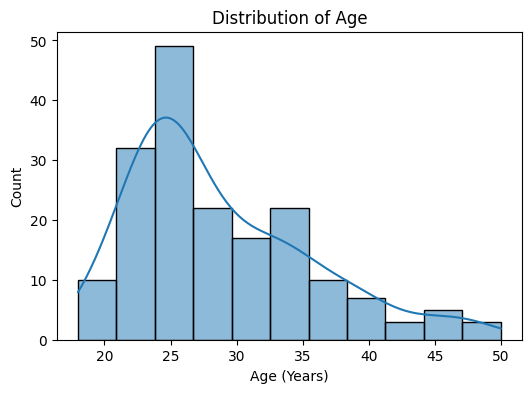

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="Age", kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age (Years)")
plt.ylabel("Count")
plt.show()

### Key Insights

- The age distribution is slightly right-skewed, with the majority of customers concentrated between 23 and 30 years.
- The highest concentration of customers is around 25 years, indicating that young adults form the largest customer segment.
- The number of customers gradually decreases with increasing age, with relatively few customers above 40 years.


### 8.1.2 Distribution of Education

The distribution of customers years of education is visualized using a count plot. Since education is a discrete variable with a limited number of values, a count plot provides a clear representation of the frequency of each education level.

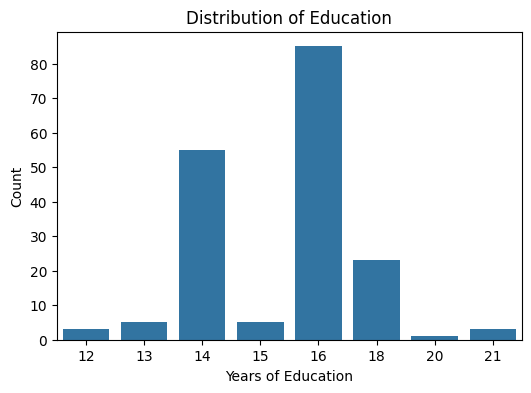

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Education")
plt.title("Distribution of Education")
plt.xlabel("Years of Education")
plt.ylabel("Count")
plt.show()

### Key Insights

- Most customers have either 14, 16, or 18 years of education.
- 16 years of education is the most common education level, followed by 14 years.
- The distribution indicates that the majority of customers have 14-16 years of education.

### 8.1.3 Distribution of Usage

The distribution of customers expected weekly treadmill usage is visualized using a count plot. Since usage is a discrete variable representing the number of times the treadmill is expected to be used per week, a count plot clearly shows the frequency of each usage level.

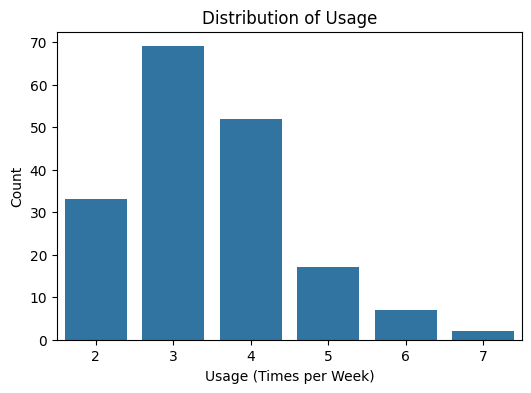

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Usage")
plt.title("Distribution of Usage")
plt.xlabel("Usage (Times per Week)")
plt.ylabel("Count")
plt.show()

### Key Insights

- Most customers expect to use the treadmill 3 or 4 times per week.
- Usage of 3 times per week is the most common among customers.
- The number of customers planning to use the treadmill decreases as the expected weekly usage increases beyond 4 times.


### 8.1.4 Distribution of Fitness

The distribution of customers self-rated fitness levels is visualized using a count plot. Since fitness is measured on a discrete scale of 1 to 5, a count plot clearly shows the frequency of each fitness level.

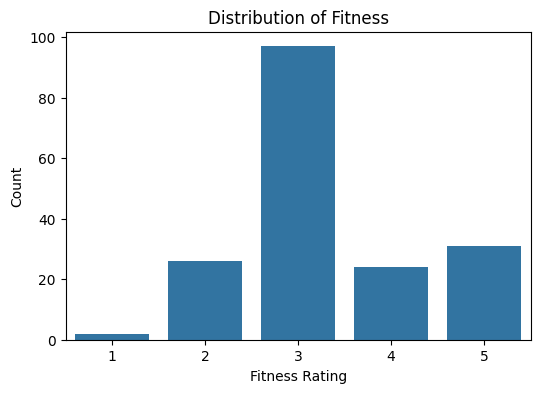

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Fitness")
plt.title("Distribution of Fitness")
plt.xlabel("Fitness Rating")
plt.ylabel("Count")
plt.show()

### Key Insights

- Most customers have a fitness rating of 3, making it the most common fitness level.
- Only a very small number of customers have the lowest fitness rating of 1.
- The distribution suggests that the majority of customers consider themselves to have an average level of fitness.

### 8.1.5 Distribution of Income

The distribution of customers annual income is visualized using a histogram with a Kernel Density Estimation (KDE) curve. This helps understand the income distribution and identify whether customers are concentrated within specific income ranges.

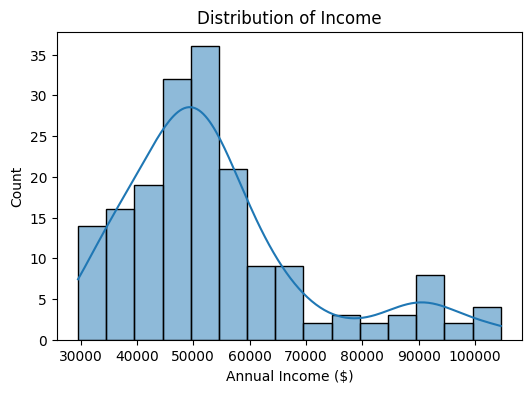

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="Income", kde=True)
plt.title("Distribution of Income")
plt.xlabel("Annual Income ($)")
plt.ylabel("Count")
plt.show()

### Key Insights

- Most customers have an annual income between 40,000 and 60,000.
- The income distribution is right-skewed, with a small number of customers having substantially higher incomes.
- The highest concentration of customers is around an annual income of 50,000.


### 8.1.6 Distribution of Miles

The distribution of customers expected weekly mile count is visualized using a histogram with a Kernel Density Estimation (KDE) curve. This helps understand the expected weekly distance customers plan to walk or run on the treadmill.

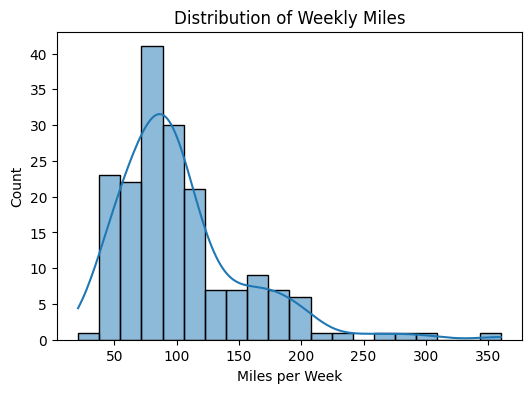

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="Miles", kde=True)
plt.title("Distribution of Weekly Miles")
plt.xlabel("Miles per Week")
plt.ylabel("Count")
plt.show()

### Key Insights

- Most customers expect to walk or run between 50 and 120 miles per week.
- The weekly miles distribution is right-skewed, with a small number of customers expecting to cover substantially higher distances.
- The highest concentration of customers is around 80-100 miles per week.
- Only a small proportion of customers expect to walk or run more than 200 miles per week.

## 8.2 Bivariate Analysis

Bivariate analysis examines the relationship between two variables to identify patterns, associations, and differences across customer groups. In this section, various visualizations are used to compare customer characteristics across treadmill products and understand the factors influencing product preference.

### 8.2.1 Product Preference by Gender

This analysis examines the relationship between treadmill product preference and customer gender. A count plot is used to compare the number of male and female customers purchasing each treadmill model.

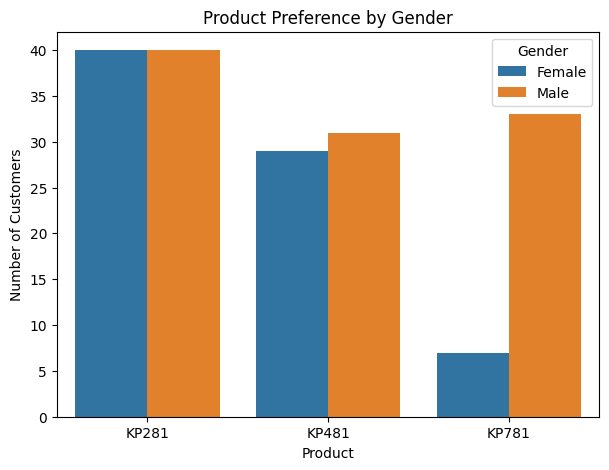

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Product", hue="Gender")
plt.title("Product Preference by Gender")
plt.xlabel("Product")
plt.ylabel("Number of Customers")
plt.show()

### Key Insights

- KP281 is purchased equally by male and female customers.
- KP481 is also purchased by both genders, with a slightly higher number of male customers.
- KP781 is predominantly purchased by male customers, while comparatively few female customers purchase this model.
- The preference gap between male and female customers becomes more pronounced for the premium treadmill model (KP781).

### 8.2.2 Product Preference by Marital Status

This analysis examines the relationship between treadmill product preference and customers' marital status. A count plot is used to compare the distribution of each treadmill model among single and partnered customers.

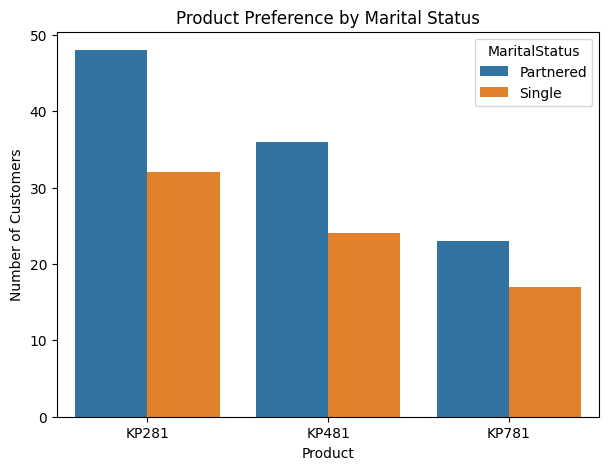

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Product", hue="MaritalStatus")
plt.title("Product Preference by Marital Status")
plt.xlabel("Product")
plt.ylabel("Number of Customers")
plt.show()

### Key Insights

- KP281 has the highest number of purchases among both partnered and single customers.
- Across all three treadmill models, partnered customers outnumber single customers.
- The difference between partnered and single customers is relatively consistent across the product range.
- Marital status does not appear to have a strong influence on treadmill product preference.

### 8.2.3 Age Distribution by Product

This analysis compares the age distribution of customers across the three treadmill models using a box plot. It helps identify differences in the age profile of customers purchasing each product.

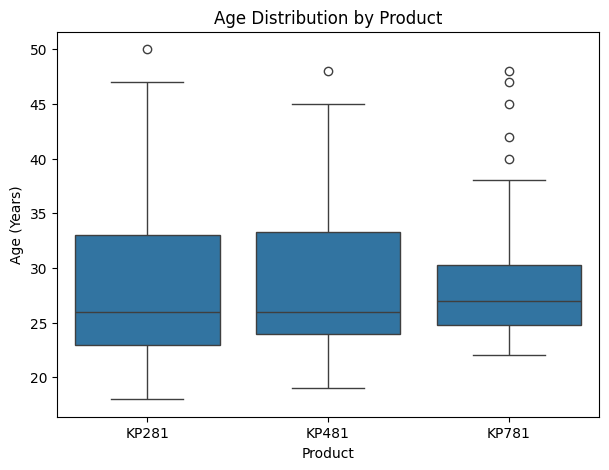

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Product", y="Age")
plt.title("Age Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Age (Years)")
plt.show()

### Key Insights

- The median age of customers is similar across all three treadmill models, indicating that age alone does not strongly differentiate product preference.
- KP281 and KP481 exhibit a wider spread in customer age compared to KP781.
- KP781 customers are more concentrated within a narrower age range, although a few older customers are present as outliers.
- All three products contain a few older-age outliers, suggesting that treadmill purchases are not limited to younger customers.

### 8.2.4 Usage Distribution by Product

This analysis compares the expected weekly treadmill usage across the three treadmill models using a grouped count plot. It helps identify how customers with different usage frequencies are distributed across the product range.

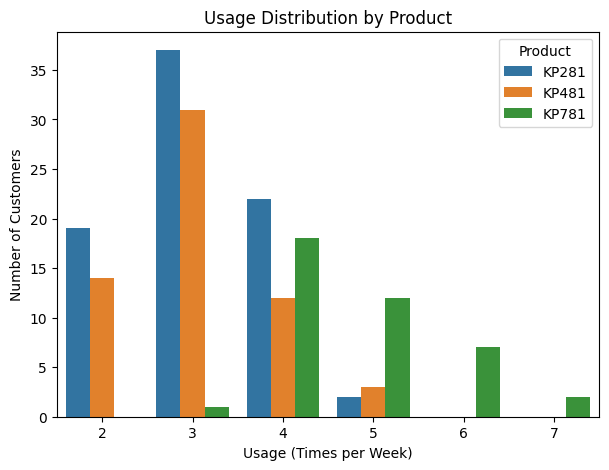

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Usage", hue="Product")
plt.title("Usage Distribution by Product")
plt.xlabel("Usage (Times per Week)")
plt.ylabel("Number of Customers")
plt.show()

### Key Insights

- Most KP281 and KP481 customers expect to use the treadmill 3 times per week.
- KP781 customers are concentrated at higher usage levels, with most expecting to use the treadmill 4–6 times per week.
- Very few KP281 and KP481 customers expect to use the treadmill more than 5 times per week.
- Customers expecting more frequent weekly usage are more likely to purchase the premium KP781 treadmill.

### 8.2.5 Fitness Distribution by Product

This analysis compares customers self-rated fitness levels across the three treadmill models using a grouped count plot. It helps identify how fitness levels vary among customers purchasing different treadmill products.

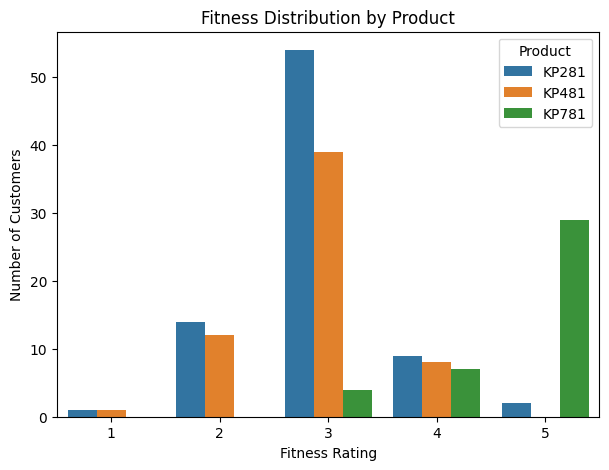

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="Fitness",hue="Product")
plt.title("Fitness Distribution by Product")
plt.xlabel("Fitness Rating")
plt.ylabel("Number of Customers")
plt.legend(title="Product")
plt.show()

### Key Insights

- KP281 and KP481 customers are predominantly concentrated at a fitness rating of 3, indicating an average self-reported fitness level.
- KP781 customers are mostly concentrated at the highest fitness rating of 5, with comparatively few customers reporting lower fitness levels.
- Very few customers across all treadmill models have a fitness rating of 1.
- The distribution suggests that customers with higher self-rated fitness levels are more likely to purchase the premium KP781 treadmill.

### 8.2.6 Income Distribution by Product

This analysis compares the annual income distribution of customers across the three treadmill models using a box plot. It helps identify whether customers purchasing different treadmill models belong to different income groups.

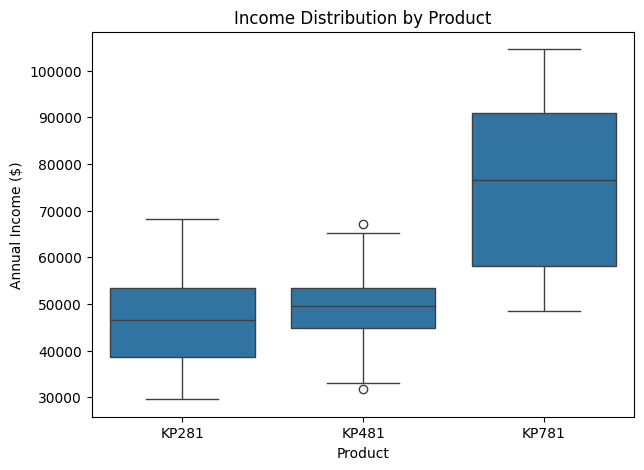

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Product", y="Income")
plt.title("Income Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Annual Income ($)")
plt.show()

### Key Insights

- KP781 customers have substantially higher annual incomes compared to customers purchasing KP281 and KP481.
- The income distributions of KP281 and KP481 are relatively similar, with KP481 showing a slightly higher median income.
- KP781 exhibits a much wider income range, indicating that customers purchasing the premium treadmill belong to a broader high-income segment.
- The clear difference in income distribution suggests that annual income is an important factor influencing the purchase of the premium KP781 treadmill.

## 8.3 Multivariate Analysis

Multivariate analysis examines the relationship among three or more variables simultaneously. This helps uncover customer segments, identify interactions between variables and gain deeper insights into the factors influencing treadmill purchases.

### 8.3.1 Income vs Weekly Miles by Product

This scatter plot examines the relationship between annual income and expected weekly mileage while distinguishing customers by treadmill product. It helps identify customer segments and understand how product preference varies across different income and usage levels.

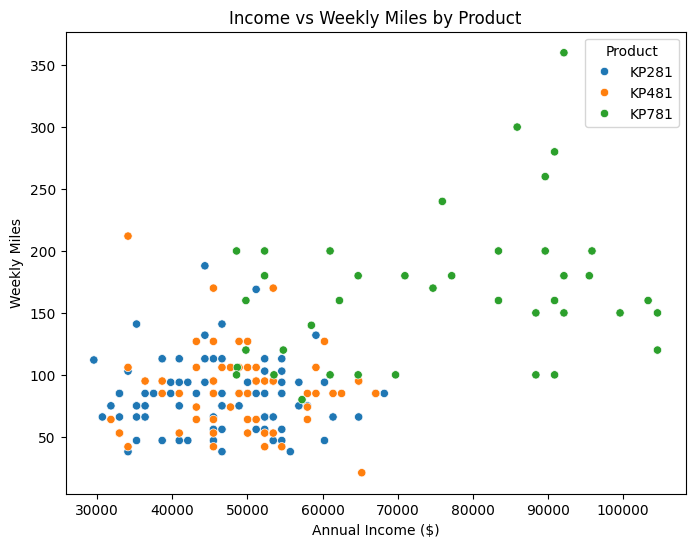

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Income", y="Miles", hue="Product")
plt.title("Income vs Weekly Miles by Product")
plt.xlabel("Annual Income ($)")
plt.ylabel("Weekly Miles")
plt.legend(title="Product")
plt.show()

### Key Insights

- KP281 customers are primarily concentrated in the lower income and lower weekly mile count segment.
- KP481 customers show considerable overlap with KP281, indicating similar customer characteristics.
- KP781 customers are predominantly concentrated in the higher income and higher weekly mileage segment, forming a distinct customer group.
- The scatter plot highlights clear customer segmentation, suggesting that annual income and expected weekly mileage are key factors influencing the purchase of the premium KP781 treadmill.

### 8.3.2 Correlation Heatmap

The correlation heatmap visualizes the strength and direction of linear relationships among the numerical variables. It helps identify which customer characteristics are closely associated and provides additional insights into factors influencing treadmill usage and product preference.

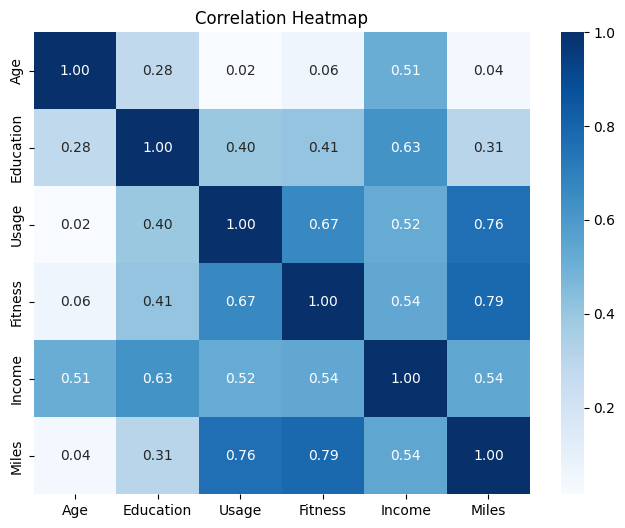

In [ ]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Key Insights

- Weekly Miles has a strong positive correlation with Fitness (0.79) and Usage (0.76), indicating that fitter customers and those who use the treadmill more frequently tend to cover greater weekly distances.
- Usage and Fitness are strongly positively correlated (0.67), suggesting that customers with higher fitness levels are more likely to use the treadmill more frequently.
- Income shows a moderate positive correlation with Education (0.63), Fitness (0.54), Miles (0.54), and Usage (0.52), indicating that higher-income customers generally have higher education levels and tend to use the treadmill more frequently.
- Age has a moderate positive correlation with Income (0.51) but exhibits little to no correlation with Usage (0.02), Fitness (0.06), and Miles (0.04), suggesting that age alone is not a strong indicator of treadmill usage behavior.

# 9. Probability Analysis

Probability analysis helps quantify the likelihood of different customer characteristics and product preferences. This section uses contingency tables along with joint, marginal, and conditional probabilities to understand the relationship between treadmill products and customer attributes.

The following measures are used throughout this section:



## Contingency Table

A contingency table presents the frequency distribution of customers across treadmill products and a selected customer attribute. It forms the basis for computing joint, marginal, and conditional probabilities.



## Joint Probability

Joint probability represents the probability of simultaneously observing a specific treadmill product and a customer attribute. It is calculated by dividing each cell frequency by the total number of customers.



## Marginal Probability

Marginal probability represents the overall probability of observing a single variable independently of the other variable. It is calculated using the row totals or column totals divided by the total number of customers.



## Conditional Probability

Conditional probability represents the probability of one event occurring given that another event has already occurred. In this analysis, it is used to determine:
- The probability of purchasing a treadmill product given a customer attribute.
- The probability of observing a customer attribute given the treadmill product purchased.

## 9.1 Product vs Gender


### Contingency Table


In [ ]:
pd.crosstab(df["Product"], df["Gender"], margins = True)

Gender,Female,Male,All
Product,,,
KP281,40,40,80
KP481,29,31,60
KP781,7,33,40
All,76,104,180


### Joint Probability and Marginal Probability


In [ ]:
(pd.crosstab(df["Product"],df["Gender"],margins=True) / len(df)).round(2)

Gender,Female,Male,All
Product,,,
KP281,0.22,0.22,0.44
KP481,0.16,0.17,0.33
KP781,0.04,0.18,0.22
All,0.42,0.58,1.00


### Conditional Probability (Product | Gender)


In [ ]:
gender_ct = pd.crosstab(df["Product"], df["Gender"])
gender_ct.div(gender_ct.sum(axis=0), axis=1).round(2)

Gender,Female,Male
Product,,
KP281,0.53,0.38
KP481,0.38,0.30
KP781,0.09,0.32


### Conditional Probability (Gender | Product)


In [ ]:
gender_ct.div(gender_ct.sum(axis=1), axis=0).round(2)

Gender,Female,Male
Product,,
KP281,0.50,0.50
KP481,0.48,0.52
KP781,0.18,0.82


### Key Insights

- KP281 has the highest overall purchase probability (44%), followed by KP481 (33%) and KP781 (22%), indicating that KP281 is the most preferred treadmill model among customers.
- Male customers constitute a larger proportion of the customer base (58%) than female customers (42%).
- Given a female customer, the probability of purchasing KP281 (53%) is higher than KP481 (38%) and KP781 (9%), suggesting that female customers predominantly prefer entry-level and mid-range treadmill models.
- Given a male customer, KP281 remains the most preferred model (38%), while the probability of purchasing KP781 (32%) is considerably higher than that of female customers.
- Given a KP781 purchase, there is an 82% probability that the customer is male, indicating that the premium treadmill is predominantly purchased by male customers.
- KP281 exhibits an equal gender distribution (50% male and 50% female), whereas KP481 also maintains a relatively balanced customer base with a slight male preference(52% male and 48% female).

## 9.2 Product vs Marital Status


### Contingency Table


In [ ]:
pd.crosstab(df["Product"], df["MaritalStatus"], margins=True)

MaritalStatus,Partnered,Single,All
Product,,,
KP281,48,32,80
KP481,36,24,60
KP781,23,17,40
All,107,73,180


### Joint Probability and Marginal Probability

In [ ]:
(pd.crosstab(df["Product"],df["MaritalStatus"],margins=True) / len(df)).round(2)

MaritalStatus,Partnered,Single,All
Product,,,
KP281,0.27,0.18,0.44
KP481,0.20,0.13,0.33
KP781,0.13,0.09,0.22
All,0.59,0.41,1.00


### Conditional Probability (Product | Marital Status)


In [ ]:
marital_ct = pd.crosstab(df["Product"], df["MaritalStatus"])
marital_ct.div(marital_ct.sum(axis=0), axis=1).round(2)

MaritalStatus,Partnered,Single
Product,,
KP281,0.45,0.44
KP481,0.34,0.33
KP781,0.21,0.23


### Conditional Probability (Marital Status | Product)


In [ ]:
marital_ct.div(marital_ct.sum(axis=1), axis=0).round(2)

MaritalStatus,Partnered,Single
Product,,
KP281,0.60,0.40
KP481,0.60,0.40
KP781,0.57,0.42


### Key Insights

- The overall customer base consists of 59% partnered customers and 41% single customers.
- KP281 is the most preferred treadmill among both partnered (45%) and single (44%) customers, followed by KP481 and KP781, indicating that marital status has minimal influence on product preference.
- Given a partnered customer, the probability of purchasing KP281 (45%) is slightly higher than KP481 (34%) and KP781 (21%).
- Given a single customer, the probability of purchasing KP281 (44%) remains the highest, followed by KP481 (33%) and KP781 (23%).
- Given a purchase of KP281 or KP481, there is a 60% probability that the customer is partnered and a 40% probability that the customer is single.
- For KP781, the customer distribution is also similar, with 57% partnered and 42% single customers.

## 9.3 Product vs Age

Since age is a continuous variable, it is categorized into meaningful age groups to facilitate probability analysis. The age groups used in this analysis are:

- Young Adults (18–25 years)
- Adults (26–35 years)
- Middle-aged (36–45 years)
- Older Adults (46 years and above)


In [ ]:
df["AgeGroup"] = pd.cut(df["Age"],bins=[15, 25, 35, 45, 55],
labels=["Young Adults", "Adults", "Middle-aged", "Older Adults"])

###Contingency Table

In [ ]:
pd.crosstab(df["Product"],df["AgeGroup"], margins = True)

AgeGroup,Young Adults,Adults,Middle-aged,Older Adults,All
Product,,,,,
KP281,34,32,11,3,80
KP481,28,24,7,1,60
KP781,17,17,4,2,40
All,79,73,22,6,180


### Joint Probability and Marginal Probability

In [ ]:
(pd.crosstab(df["Product"],df["AgeGroup"], margins = True)/len(df)).round(2)

AgeGroup,Young Adults,Adults,Middle-aged,Older Adults,All
Product,,,,,
KP281,0.19,0.18,0.06,0.02,0.44
KP481,0.16,0.13,0.04,0.01,0.33
KP781,0.09,0.09,0.02,0.01,0.22
All,0.44,0.41,0.12,0.03,1.00


### Conditional Probability (Product | Age group)


In [ ]:
agegroup_ct = pd.crosstab(df["Product"],df["AgeGroup"])
agegroup_ct.div(agegroup_ct.sum(axis=0),axis=1).round(2)

AgeGroup,Young Adults,Adults,Middle-aged,Older Adults
Product,,,,
KP281,0.43,0.44,0.50,0.50
KP481,0.35,0.33,0.32,0.17
KP781,0.22,0.23,0.18,0.33


### Conditional Probability (Age group | Product)

In [ ]:
agegroup_ct.div(agegroup_ct.sum(axis=1),axis=0).round(2)

AgeGroup,Young Adults,Adults,Middle-aged,Older Adults
Product,,,,
KP281,0.42,0.40,0.14,0.04
KP481,0.47,0.40,0.12,0.02
KP781,0.42,0.42,0.10,0.05


### Key Insights

- Young Adults (44%) and Adults (41%) constitute the majority of the customer base, while Middle-aged (12%) and Older Adults (3%) account for a smaller share.
- KP281 is the most preferred treadmill across all age groups, with approximately 43–50% of customers in each age group choosing this model.
- Among Young Adults, 43% prefer KP281, followed by KP481 (35%) and KP781 (22%).
- Among Adults, customer preferences remain similar, with KP281 (44%) being the most preferred model, followed by KP481 (33%) and KP781 (23%).
- Middle-aged customers also show the highest preference for KP281 (50%), indicating a consistent preference for the entry-level treadmill across age groups.
- Given a purchase of KP281, 42% of customers are Young Adults and 40% are Adults, while only 18% belong to the Middle-aged and Older Adults categories combined.
- The age distribution across all three treadmill products is relatively similar, suggesting that age has a limited influence on treadmill preference compared to other factors such as income, fitness level, and usage frequency.

## 9.4 Product vs Education

Since education is represented as the number of years of education, it is treated as a discrete numerical variable. To facilitate probability analysis, the values are grouped into meaningful education ranges.

In [ ]:
df["EducationGroup"] = pd.cut(df["Education"], bins=[11, 14, 16, 18, 21],
labels=["12-14 Years", "15-16 Years", "17-18 Years", "19-21 Years"])

###Contingency Table

In [ ]:
pd.crosstab(df["Product"], df["EducationGroup"], margins=True)


EducationGroup,12-14 Years,15-16 Years,17-18 Years,19-21 Years,All
Product,,,,,
KP281,35,43,2,0,80
KP481,26,32,2,0,60
KP781,2,15,19,4,40
All,63,90,23,4,180


###Joint Probability and Marginal Probability

In [ ]:
(pd.crosstab(df["Product"], df["EducationGroup"], margins=True) / len(df)).round(2)

EducationGroup,12-14 Years,15-16 Years,17-18 Years,19-21 Years,All
Product,,,,,
KP281,0.19,0.24,0.01,0.00,0.44
KP481,0.14,0.18,0.01,0.00,0.33
KP781,0.01,0.08,0.11,0.02,0.22
All,0.35,0.50,0.13,0.02,1.00


###Conditional Probability (Product | Education Group)

In [ ]:
education_ct = pd.crosstab(df["Product"], df["EducationGroup"])
education_ct.div(education_ct.sum(axis=0), axis=1).round(2)

EducationGroup,12-14 Years,15-16 Years,17-18 Years,19-21 Years
Product,,,,
KP281,0.56,0.48,0.09,0.0
KP481,0.41,0.36,0.09,0.0
KP781,0.03,0.17,0.83,1.0


###Conditional Probability (Education Group | Product)

In [ ]:
education_ct.div(education_ct.sum(axis=1), axis=0).round(2)

EducationGroup,12-14 Years,15-16 Years,17-18 Years,19-21 Years
Product,,,,
KP281,0.44,0.54,0.02,0.0
KP481,0.43,0.53,0.03,0.0
KP781,0.05,0.38,0.48,0.1


### Key Insights

- Customers with 15–16 years of education form the largest group, accounting for 50% of the total customer base, followed by 12–14 years (35%) and 17–18 years (13%).
- Among customers with 12–14 years of education, KP281 is the most preferred product (56%), followed by KP481 (41%), while KP781 has very low preference (3%).
- Among customers with 15–16 years of education, KP281 remains the most preferred product (48%), followed by KP481 (36%) and KP781 (17%).
- Among customers with 17–18 years of education, KP781 is the most preferred product (83%), while KP281 and KP481 each account for only 9%.
- Looking at education distribution within each product, KP281 and KP481 customers are predominantly from the 12–16 years education groups, while KP781 has a much higher proportion of customers with 17–18 years of education (48%).
- Overall, education appears to have a noticeable relationship with product preference, with higher education levels being more strongly associated with the premium KP781 treadmill.
- The 19–21 years education group contains only 4 customers, so conclusions for this group should be interpreted cautiously.


## 9.5 Product vs Income

Since income is a continuous variable, it is categorized into meaningful income groups to facilitate probability analysis. The income groups used in this analysis are:

- Lower: Income ≤ 50,000
- Middle: Income > 50,000 and ≤ 70,000
- Upper-Middle: Income > 70,000 and ≤ 90,000
- High: Income > 90,000



In [ ]:
df["IncomeGroup"] = pd.cut(df["Income"], bins=[29000, 50000, 70000, 90000, 105000],
labels=["Lower", "Middle", "Upper-Middle", "High"])

###Contingency Table

In [ ]:
pd.crosstab(df["Product"], df["IncomeGroup"], margins=True)

IncomeGroup,Lower,Middle,Upper-Middle,High,All
Product,,,,,
KP281,48,32,0,0,80
KP481,30,30,0,0,60
KP781,5,12,11,12,40
All,83,74,11,12,180


###Joint Probability and Marginal Probability

In [ ]:
(pd.crosstab(df["Product"], df["IncomeGroup"], margins=True) / len(df)).round(2)

IncomeGroup,Lower,Middle,Upper-Middle,High,All
Product,,,,,
KP281,0.27,0.18,0.00,0.00,0.44
KP481,0.17,0.17,0.00,0.00,0.33
KP781,0.03,0.07,0.06,0.07,0.22
All,0.46,0.41,0.06,0.07,1.00


###Conditional Probability (Product | Income Group)

In [ ]:
income_ct = pd.crosstab(df["Product"], df["IncomeGroup"])
income_ct.div(income_ct.sum(axis=0), axis=1).round(2)

IncomeGroup,Lower,Middle,Upper-Middle,High
Product,,,,
KP281,0.58,0.43,0.0,0.0
KP481,0.36,0.41,0.0,0.0
KP781,0.06,0.16,1.0,1.0


###Conditional Probability (Income Group | Product)

In [ ]:
income_ct.div(income_ct.sum(axis=1), axis=0).round(2)

IncomeGroup,Lower,Middle,Upper-Middle,High
Product,,,,
KP281,0.60,0.4,0.00,0.0
KP481,0.50,0.5,0.00,0.0
KP781,0.12,0.3,0.28,0.3


### Key Insights

- Lower-income customers form the largest group, accounting for 46% of the customer base, followed by Middle-income customers at 41%.
- Among Lower-income customers, KP281 is the most preferred product (58%), followed by KP481 (36%) and KP781 (6%).
- Among Middle-income customers, KP281 (43%) and KP481 (41%) have similar preference, while KP781 accounts for 16%.
- All customers in the Upper-Middle income group and High income group purchased KP781, indicating a strong association between higher income and the premium treadmill. However, each group contains only 11 and 12 customers respectively, so the result should be interpreted cautiously.
- Looking at each product, KP281 and KP481 customers are concentrated in the Lower and Middle income groups, whereas KP781 has a substantially higher representation among Upper-Middle and High-income customers.
- Overall, income appears to be a strong differentiating factor for product preference, with KP781 being associated more strongly with higher-income customers.

## 9.6 Product vs Fitness


###Contingency Table

In [ ]:
pd.crosstab(df["Product"], df["Fitness"], margins=True)


Fitness,1,2,3,4,5,All
Product,,,,,,
KP281,1,14,54,9,2,80
KP481,1,12,39,8,0,60
KP781,0,0,4,7,29,40
All,2,26,97,24,31,180


###Joint Probability and Marginal Probability

In [ ]:
(pd.crosstab(df["Product"], df["Fitness"], margins=True) / len(df)).round(2)

Fitness,1,2,3,4,5,All
Product,,,,,,
KP281,0.01,0.08,0.30,0.05,0.01,0.44
KP481,0.01,0.07,0.22,0.04,0.00,0.33
KP781,0.00,0.00,0.02,0.04,0.16,0.22
All,0.01,0.14,0.54,0.13,0.17,1.00


###Conditional Probability (Product | Fitness)

In [ ]:
fitness_ct = pd.crosstab(df["Product"], df["Fitness"])
fitness_ct.div(fitness_ct.sum(axis=0), axis=1).round(2)

Fitness,1,2,3,4,5
Product,,,,,
KP281,0.5,0.54,0.56,0.38,0.06
KP481,0.5,0.46,0.40,0.33,0.00
KP781,0.0,0.00,0.04,0.29,0.94


###Conditional Probability (Fitness | Product)

In [ ]:
fitness_ct.div(fitness_ct.sum(axis=1), axis=0).round(2)

Fitness,1,2,3,4,5
Product,,,,,
KP281,0.01,0.18,0.68,0.11,0.02
KP481,0.02,0.20,0.65,0.13,0.00
KP781,0.00,0.00,0.10,0.18,0.72


### Key Insights

- Fitness level shows a strong relationship with treadmill product preference, particularly for the premium KP781 model.
- Among customers with fitness ratings of 1 and 2, KP281 and KP481 are the only products purchased, with KP781 having no customers in these fitness categories.
- Among customers with a fitness rating of 3, KP281 is the most preferred product (56%), followed by KP481 (40%), while KP781 has very low preference (4%).
- For customers with a fitness rating of 4, KP281 has the highest preference (38%), followed by KP481 (33%) and KP781 (29%).
- Among customers with a fitness rating of 5, KP781 dominates with 94% of customers, while KP281 accounts for only 6% and KP481 has no customers.
- Looking at each product, KP281 customers are predominantly concentrated at fitness rating 3 (68%), while KP481 customers are also mainly concentrated at rating 3 (65%).
- KP781 customers are strongly concentrated at higher fitness levels, with 72% having a fitness rating of 5 and another 18% having a rating of 4.


## 9.7 Product vs Usage

Since usage represents the number of times customers use the treadmill per week, it is grouped into three meaningful usage levels to facilitate probability analysis:

- Low: 1–3 times per week
- Medium: 4–5 times per week
- High: 6–7 times per week


In [ ]:
df["UsageGroup"] = pd.cut(df["Usage"], bins=[1, 3, 5, 7],
labels=["Low", "Medium", "High"])

###Contingency Table

In [ ]:
pd.crosstab(df["Product"], df["UsageGroup"], margins=True)


UsageGroup,Low,Medium,High,All
Product,,,,
KP281,56,24,0,80
KP481,45,15,0,60
KP781,1,30,9,40
All,102,69,9,180


###Joint Probability and Marginal Probability

In [ ]:
(pd.crosstab(df["Product"], df["UsageGroup"], margins=True) / len(df)).round(2)

UsageGroup,Low,Medium,High,All
Product,,,,
KP281,0.31,0.13,0.00,0.44
KP481,0.25,0.08,0.00,0.33
KP781,0.01,0.17,0.05,0.22
All,0.57,0.38,0.05,1.00


###Conditional Probability (Product | Usage Group)

In [ ]:
usage_ct = pd.crosstab(df["Product"], df["UsageGroup"])
usage_ct.div(usage_ct.sum(axis=0), axis=1).round(2)

UsageGroup,Low,Medium,High
Product,,,
KP281,0.55,0.35,0.0
KP481,0.44,0.22,0.0
KP781,0.01,0.43,1.0


###Conditional Probability (Usage Group | Product)

In [ ]:
usage_ct.div(usage_ct.sum(axis=1), axis=0).round(2)

UsageGroup,Low,Medium,High
Product,,,
KP281,0.70,0.30,0.00
KP481,0.75,0.25,0.00
KP781,0.02,0.75,0.22


### Key Insights

- Low-usage customers form the largest group, accounting for 57% of the customer base, followed by Medium usage at 38%. High-usage customers account for only 5%.
- Among Low-usage customers, KP281 is the most preferred product (55%), followed by KP481 (44%), while KP781 has very low preference (1%).
- Among Medium-usage customers, KP281 accounts for 35% of customers, KP481 for 22%, and KP781 has the highest preference at 43%.
- All High-usage customers in the dataset purchased KP781, indicating a strong association between high treadmill usage and the premium KP781 model. However, this group contains only 9 customers, so the finding should be interpreted cautiously.
- Looking at each product, KP281 customers are predominantly Low usage (70%), while KP481 customers are also mainly Low usage (75%).
- KP781 customers are predominantly Medium usage 75%, with another 22% belonging to the High-usage group.

## 9.8 Product vs Weekly Miles

Since weekly miles is a continuous variable, it is categorized into three meaningful mileage levels to facilitate probability analysis:

- Low: 100 miles or less per week
- Medium: 101–200 miles per week
- High: More than 200 miles per week


In [ ]:
df["MilesGroup"] = pd.cut(df["Miles"], bins=[0, 100, 200, 360],
labels=["Low", "Medium", "High"])

###Contingency Table

In [ ]:
pd.crosstab(df["Product"], df["MilesGroup"], margins=True)


MilesGroup,Low,Medium,High,All
Product,,,,
KP281,62,18,0,80
KP481,44,15,1,60
KP781,8,27,5,40
All,114,60,6,180


###Joint Probability and Marginal Probability

In [ ]:
(pd.crosstab(df["Product"], df["MilesGroup"], margins=True) / len(df)).round(2)

MilesGroup,Low,Medium,High,All
Product,,,,
KP281,0.34,0.10,0.00,0.44
KP481,0.24,0.08,0.01,0.33
KP781,0.04,0.15,0.03,0.22
All,0.63,0.33,0.03,1.00


###Conditional Probability (Product | Miles Group)

In [ ]:
miles_ct = pd.crosstab(df["Product"], df["MilesGroup"])
miles_ct.div(miles_ct.sum(axis=0), axis=1).round(2)

MilesGroup,Low,Medium,High
Product,,,
KP281,0.54,0.30,0.00
KP481,0.39,0.25,0.17
KP781,0.07,0.45,0.83


###Conditional Probability (Miles Group | Product)

In [ ]:
miles_ct.div(miles_ct.sum(axis=1), axis=0).round(2)

MilesGroup,Low,Medium,High
Product,,,
KP281,0.78,0.22,0.00
KP481,0.73,0.25,0.02
KP781,0.20,0.68,0.12


### Key Insights

- Low-mile count customers form the largest group, accounting for 63% of the customer base, followed by Medium mile count at 33%. High-mile count customers account for only 3%.
- Among Low-mile count customers, KP281 is the most preferred product (54%), followed by KP481 (39%), while KP781 accounts for only 7%.
- Among Medium-mile count customers, KP781 has the highest preference (45%), followed by KP281 (30%) and KP481 (25%).
- Among High-mile count customers, KP781 dominates with 83% of customers, while KP481 accounts for 17% and KP281 has no customers in this group. However, this group contains only 6 customers, so the result should be interpreted cautiously.
- Looking at each product, KP281 customers are predominantly Low mile count customers (78%), while KP481 customers are also mainly Low mile count customers (73%).
- KP781 customers are more concentrated among Medium and High mile count, with 68% in the Medium group and 12% in the High group.

## 10. Customer Profiling

Based on the descriptive, bivariate, multivariate and probability analyses, customer profiles are developed for each AeroFit treadmill product. The profiles focus on the key customer characteristics associated with each product and help identify the type of customer for whom each treadmill may be suitable.

### 10.1 KP281 - Customer Profile

KP281 is the entry-level treadmill priced at $1,500. Based on the descriptive, bivariate, multivariate and probability analyses, the typical KP281 customer can be characterized as follows:

- KP281 is the most purchased treadmill, accounting for approximately 44% of total purchases.
- The product has an almost equal gender distribution, indicating that it appeals to both male and female customers.
- The majority of KP281 customers belong to the Young Adults and Adults age groups.
- Customers are predominantly from the Lower and Middle income groups.
- Most KP281 customers have a fitness rating of 3, indicating a moderate level of fitness.
- The majority of KP281 customers fall into the Low usage category, using the treadmill around 2–3 times per week.
- Most KP281 customers also fall into the Low weekly mile count category.
- Customers are primarily concentrated in the 12–16 years education range.
- The product has a relatively balanced distribution across partnered and single customers, with partnered customers forming a slightly larger share.

Overall, KP281 can be characterized as a suitable entry-level option for customers with moderate fitness levels and relatively low usage and mile count requirements.

### 10.2 KP481 – Customer Profile

KP481 is the mid-level treadmill priced at $1,750. Based on the descriptive, bivariate, multivariate and probability analyses, the typical KP481 customer can be characterized as follows:

- KP481 accounts for approximately 33% of total purchases.
- The product has a relatively balanced gender distribution, with a slight majority of male customers.
- Most KP481 customers belong to the Young Adults and Adults age groups.
- Customers are predominantly from the Lower and Middle income groups.
- Most KP481 customers have a fitness rating of 3, indicating a moderate level of fitness.
- The majority of KP481 customers fall into the Low usage category, using the treadmill around 2–3 times per week.
- Most KP481 customers also fall into the Low weekly mile count category.
- Customers are primarily concentrated in the 12–16 years education range.
- The product has a similar distribution among partnered and single customers, with partnered customers forming a slightly larger share.

Overall, KP481 can be characterized as a mid-level option for customers with moderate fitness levels and relatively low usage and mileage requirements, with a customer profile broadly similar to KP281.

### 10.3 KP781 – Customer Profile

KP781 is the premium treadmill priced at $2,500. Based on the descriptive, bivariate, multivariate and probability analyses, the typical KP781 customer can be characterized as follows:

- KP781 accounts for approximately 22% of total purchases.
- The product is predominantly purchased by male customers.
- Most KP781 customers belong to the Young Adults and Adults age groups.
- Customers are more strongly concentrated in the Upper-Middle and High income groups compared with KP281 and KP481.
- KP781 has a strong association with higher fitness levels, particularly fitness ratings of 4 and 5.
- Most KP781 customers fall into the Medium usage category, with a smaller but notable proportion in the High usage category.
- KP781 customers are more strongly associated with Medium and High weekly mileage compared with the other two products.
- Customers with 17–18 years of education show a strong preference for KP781.
- The product has a relatively similar distribution across partnered and single customers, indicating that marital status is not a major differentiating factor.

Overall, KP781 can be characterized as a premium option for higher-income and higher-fitness customers who have greater usage and high mile count requirements.

### 10.4 Comparison of Customer Profiles

| Characteristic | KP281 | KP481 | KP781 |
|---|---|---|---|
| Product Positioning | Entry-level | Mid-level | Premium |
| Gender | Relatively balanced | Relatively balanced, slight male preference | Predominantly male |
| Age | Mainly Young Adults and Adults | Mainly Young Adults and Adults | Mainly Young Adults and Adults |
| Income | Lower to Middle | Lower to Middle | Upper-Middle to High |
| Education | Mainly 12–16 years | Mainly 12–16 years | Stronger association with 17–18 years |
| Fitness | Mostly moderate | Mostly moderate | Mostly high |
| Usage | Mostly Low | Mostly Low | Mostly Medium to High |
| Weekly Miles | Mostly Low | Mostly Low | Mostly Medium to High |
| Marital Status | No major differentiation | No major differentiation | No major differentiation |

## 11. Recommendations

###Use fitness rating and planned usage as the primary sorting questions — not demographics

Fitness level and weekly usage showed the strongest link to product choice (94% of fitness-5 customers and 100% of high-usage customers bought KP781). Age and marital status showed almost no difference across products. Any in-store quiz or online recommendation tool should lead with "How many times a week will you use it?" and "How would you rate your fitness (1–5)?" rather than asking about age or relationship status.



###Set income as a soft upsell trigger, not a hard rule.
Customers earning above $70,000 bought KP781 100% of the time in this data, but that group is only 23 customers — too small to treat as a guarantee. Sales staff can use income as a conversation starter for the premium model, but should confirm fitness level and intended usage before recommending KP781, so customers aren't pushed into a product they won't use.

###Don't recommend KP781 to low-fitness or low-usage customers, even if they can afford it.
Nobody with a fitness rating of 1 or 2 bought KP781 in this dataset. Recommending the premium treadmill to someone in that range risks a mismatched purchase and a possible return or bad review. KP281 or KP481 is the safer fit here regardless of income.


###Investigate the gender gap in KP781 sales.
82% of KP781 buyers are male, compared to a roughly even split for KP281. This could mean marketing has been unintentionally male-skewed, or that the product itself (styling, messaging) isn't resonating with women. Worth a small follow-up survey with female customers who bought KP281/KP481 to see if they considered KP781 and why they didn't choose it.




###Target higher-education channels for KP781 marketing.
Customers with 17–18 years of education bought KP781 83% of the time. Advertising through channels like corporate wellness programs, university alumni networks, or professional/LinkedIn-style platforms is likely to reach this segment more efficiently than general retail advertising.


### Stop segmenting marketing campaigns by age or marital status.
Both factors showed nearly identical purchase patterns across all three products. Budget currently spent tailoring messages by age group or relationship status would be better spent on fitness and usage-based targeting instead.



###Clarify the difference between KP281 and KP481 at point of sale.
These two products attract almost identical customers (similar income, fitness, usage, age). Since there's no natural customer split, the sales team should differentiate them by concrete features and price difference ($250) rather than by "who they're for," since the data shows they're for the same people.

### Plan inventory around the 44% / 33% / 22% split.
KP281 accounts for nearly half of all purchases, KP481 about a third, and KP781 just over a fifth. Unless a specific marketing push (like the education-channel idea above) is underway, stock levels and store floor space should roughly mirror this ratio to avoid overstocking the premium model or running short on the entry-level one.



###Treat the high-income/high-usage KP781 findings as directional, not definitive.
Several of the strongest patterns (100% of high-income and high-usage customers buying KP781) come from very small subgroups (9–23 customers). AeroFit should keep collecting purchase data over the next few quarters to confirm these patterns hold at scale before making major marketing or stocking decisions based on them.